# Model Training v2 — Grouped Multi-class Pipeline

Improvements over v1:
- **Configurable grouping map**: related diagnoses can be merged via `DISEASE_GROUP_MAP` at the top of the notebook
- **Single token per speaker**: uses sustained /a/ at normal pitch (`a_n`) — the standard clinical voice assessment vowel — giving one independent sample per speaker
- **Stratified grouped splitting**: guarantees every class/group appears in both train and test sets with no speaker leakage
- **Aggressive dimensionality reduction**: `SelectKBest(k=50)` to combat curse of dimensionality
- **Flexible class filtering**: `MIN_SAMPLES_PER_CLASS` is applied after optional grouping

> Note: Splits are now speaker-grouped and stratified by pathology to prevent data leakage.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, StratifiedGroupKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append("..")
from src.features import FeatureOptions, load_feature_tables

In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Cap per-class samples (applied after token filtering)
MAX_SAMPLES_PER_CLASS = 200

# Drop any pathology class (or pathology-group) with fewer than this many samples
MIN_SAMPLES_PER_CLASS = 50

# Number of best features to keep (aggressive reduction)
N_SELECT_FEATURES = 50

# Use a single vowel token per speaker instead of all tokens
# "a_n" = sustained /a/ at normal pitch — standard clinical voice assessment token
# Set to None to use all tokens
SELECTED_TOKEN = "a_n"

# === Target grouping configuration ===
# Pick the source label column used before grouping
TARGET_SOURCE_COL_PREFERENCE = "pathology_de"  # fallback to pathology_en if missing

# Toggle grouped target (False => original pathology labels)
USE_GROUPED_TARGET = True

# If True, labels not present in DISEASE_GROUP_MAP keep their original label.
# If False, unmapped labels are sent to UNMAPPED_LABEL.
KEEP_UNMAPPED_LABELS = True
UNMAPPED_LABEL = "Other"

# Map fine-grained diagnoses into broader groups to increase per-class sample size.
# Edit this dictionary to experiment with different grouping strategies.
DISEASE_GROUP_MAP = {
    # Neurological
    "Morbus Parkinson": "Neurological",
    "Rekurrensparese": "Neurological",
    "Spasmodische Dysphonie": "Neurological",

    # Structural / tissue-related
    "Phonationsknötchen": "Structural",
    "Phonationsknötchen": "Structural",  # unicode variant
    "Stimmlippenpolyp": "Structural",
    "Reinke Ödem": "Structural",
    "Reinke Ödem": "Structural",  # unicode variant
}

opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    selected_token=SELECTED_TOKEN,  # token filter applied at manifest level before extraction
)

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, selected_token='a_n', mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [3]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

for name, df in tables.items():
    print(f"{name}: {df.shape}")

core_df = tables["core"].copy()
acoustic_df = tables["acoustic"].copy()
multifractal_df = tables["multifractal"].copy()
opensmile_df = tables.get("opensmile", pd.DataFrame()).copy()
splits_df = tables.get("splits", pd.DataFrame())

core: (595, 18)
acoustic: (595, 87)
multifractal: (595, 17)
opensmile: (595, 91)
splits: (595, 3)


In [4]:
# Build one training table
#DEBUG
df = core_df.merge(acoustic_df, on="sample_key", how="left")
# df = core_df.copy() # temp

df = df.merge(multifractal_df, on="sample_key", how="left")
if not opensmile_df.empty:
    df = df.merge(opensmile_df, on="sample_key", how="left")
if not splits_df.empty:
    df = df.merge(splits_df, on="sample_key", how="left")

# Filter to successfully extracted samples
if "feature_status" in df.columns:
    df = df[df["feature_status"].isin(["ok", "partial_failure"])].copy()
if "acoustic_status" in df.columns:
    df = df[df["acoustic_status"] == "ok"].copy()
if "mf_status" in df.columns:
    df = df[df["mf_status"] == "ok"].copy()
if "opensmile_status" in df.columns:
    df = df[df["opensmile_status"] == "ok"].copy()

print(f"Total samples: {df.shape[0]}")
if SELECTED_TOKEN:
    print(f"Token: {SELECTED_TOKEN} (filtered at extraction level)")
df.shape

Total samples: 595
Token: a_n (filtered at extraction level)


(595, 212)

In [5]:
df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,os_spectralFluxUV_sma3nz_amean,os_loudnessPeaksPerSec,os_VoicedSegmentsPerSec,os_MeanVoicedSegmentLengthSec,os_StddevVoicedSegmentLengthSec,os_MeanUnvoicedSegmentLength,os_StddevUnvoicedSegmentLength,os_equivalentSoundLevel_dBp,split,split_seed
0,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,...,0.0,2.816901,1.538462,0.64,0.0,0.0,0.0,-15.389905,train,42
1,Phonationsknötchen::131::vowels::a_n,Phonationsknötchen::131,131,1317,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,...,0.0,3.535354,0.520833,1.91,0.0,0.0,0.0,-14.512176,val,42
2,Phonationsknötchen::870::vowels::a_n,Phonationsknötchen::870,870,1466,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,...,0.0,3.846154,2.173913,0.45,0.0,0.0,0.0,-8.524747,train,42
3,Phonationsknötchen::900::vowels::a_n,Phonationsknötchen::900,900,1492,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,m,...,0.0,5.147059,0.769231,1.29,0.0,0.0,0.0,-14.684231,test,42
4,Phonationsknötchen::1044::vowels::a_n,Phonationsknötchen::1044,1044,1540,Phonationsknötchen,Phonationsknötchen,False,vowels,a_n,w,...,0.0,6.034483,0.909091,1.09,0.0,0.0,0.0,-15.348408,train,42


In [6]:
# Build target labels (raw or grouped) and diagnose distribution BEFORE min-samples filtering
if TARGET_SOURCE_COL_PREFERENCE in df.columns:
    target_source_col = TARGET_SOURCE_COL_PREFERENCE
elif "pathology_en" in df.columns:
    target_source_col = "pathology_en"
elif "pathology_de" in df.columns:
    target_source_col = "pathology_de"
else:
    raise ValueError("Could not find pathology label column (expected pathology_de/pathology_en).")

raw_target = df[target_source_col].astype(str).str.strip()

if USE_GROUPED_TARGET:
    mapped_target = raw_target.map(DISEASE_GROUP_MAP)
    if KEEP_UNMAPPED_LABELS:
        mapped_target = mapped_target.fillna(raw_target)
    else:
        mapped_target = mapped_target.fillna(UNMAPPED_LABEL)
    df["target_label"] = mapped_target.astype(str)
else:
    df["target_label"] = raw_target

target_col = "target_label"

print(f"Target source column: {target_source_col}")
print(f"Grouped target enabled: {USE_GROUPED_TARGET}")

if USE_GROUPED_TARGET:
    print("\nRaw diagnosis -> grouped target mapping used in this run:")
    mapping_table = pd.crosstab(raw_target, df[target_col], dropna=False)
    display(mapping_table)

print("\n=== Class distribution BEFORE MIN_SAMPLES_PER_CLASS filter ===")
class_counts = df[target_col].value_counts()
display(class_counts.to_frame("count"))

# Filter out classes below minimum threshold
small_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
if small_classes:
    print(f"\nDropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {small_classes}")
    df = df[~df[target_col].isin(small_classes)].copy()

# Also show per-class speaker/recording counts
diag = df.groupby(target_col).agg(
    samples=("sample_key", "count"),
    recordings=("recording_id", "nunique"),
    speakers=("speaker_id", "nunique"),
    tokens=("token", "nunique"),
).sort_values("samples", ascending=False)

print("\n=== Class distribution AFTER filter ===")
display(diag)

Target source column: pathology_de
Grouped target enabled: True

Raw diagnosis -> grouped target mapping used in this run:


target_label,Neurological,Structural,healthy
pathology_de,,,
Morbus Parkinson,1,0,0
Phonationsknötchen,0,17,0
Reinke Ödem,0,68,0
Rekurrensparese,200,0,0
Spasmodische Dysphonie,64,0,0
Stimmlippenpolyp,0,45,0
healthy,0,0,200



=== Class distribution BEFORE MIN_SAMPLES_PER_CLASS filter ===


,count
target_label,
Neurological,265
healthy,200
Structural,130



=== Class distribution AFTER filter ===


,samples,recordings,speakers,tokens
target_label,,,,
Neurological,265,265,162,1
healthy,200,200,200,1
Structural,130,125,104,1


In [7]:
# Select target and features
exclude_cols = {
    "sample_key",
    "duplicate_class_key",
    "recording_id",
    "speaker_id",
    "wav_path",
    "feature_status",
    "feature_error",
    "acoustic_status",
    "acoustic_error",
    "mf_status",
    "mf_error",
    "opensmile_status",
    "opensmile_error",
    "split",
    "split_seed",
    "pathology_de",
    "pathology_en",
    "target_label",
}

numeric_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

categorical_feature_cols = ["sex"] if "sex" in df.columns else []

X = df[numeric_feature_cols + categorical_feature_cols].copy()
y_binary = df["is_healthy"].astype(int).copy()
y_multi = df[target_col].astype(str).copy()
groups = df["speaker_id"].copy()

print(f"Samples: {len(df)}")
print(f"Binary classes: {y_binary.nunique()}")
print(f"Multi classes: {y_multi.nunique()} — {sorted(y_multi.unique())}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Categorical features: {len(categorical_feature_cols)}")
print(f"Unique speakers: {groups.nunique()}")

Samples: 595
Binary classes: 2
Multi classes: 3 — ['Neurological', 'Structural', 'healthy']
Numeric features: 192
Categorical features: 1
Unique speakers: 457


In [8]:
# Stratified Grouped train/test split — guarantees all classes appear in both sets
# and no speaker overlaps between train and test sets.
# Ignore precomputed splits since they may not cover all classes after filtering
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
train_idx, test_idx = next(sgkf.split(X, y_multi, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_bin_train = y_binary.iloc[train_idx]
y_bin_test = y_binary.iloc[test_idx]
y_multi_train = y_multi.iloc[train_idx]
y_multi_test = y_multi.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_multi_train.value_counts())
print("\nTest class distribution:")
print(y_multi_test.value_counts())

Train shape: (476, 193)
Test shape: (119, 193)

Train class distribution:
target_label
Neurological    212
healthy         160
Structural      104
Name: count, dtype: int64

Test class distribution:
target_label
Neurological    53
healthy         40
Structural      26
Name: count, dtype: int64


In [9]:
# Shared preprocessing for numeric feature space
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("variance", VarianceThreshold(threshold=0.0)),
])

# Preprocessing for categorical feature space
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_feature_cols),
        ("cat", categorical_transformer, categorical_feature_cols)
    ],
    remainder="drop",
)

print(f"Feature selection: SelectKBest(k={N_SELECT_FEATURES}) with ANOVA F-test")

Feature selection: SelectKBest(k=50) with ANOVA F-test


In [10]:
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "SVM-RBF": SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced", verbose=-1),
}

results_bin = []
trained_pipelines_bin = {}

print("--- Binary Classification (Healthy vs Pathological) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
        ("model", model),
    ])

    pipe.fit(X_train, y_bin_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_bin_test, y_pred)
    bacc = balanced_accuracy_score(y_bin_test, y_pred)
    f1m = f1_score(y_bin_test, y_pred, average="macro", zero_division=0)

    results_bin.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_bin[name] = (pipe, y_pred)

results_bin_df = pd.DataFrame(results_bin).sort_values(by="f1_macro", ascending=False)
display(results_bin_df)

--- Binary Classification (Healthy vs Pathological) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
1,RandomForest,0.789916,0.743038,0.753010
2,SVM-RBF,0.747899,0.742247,0.729545
4,LightGBM,0.756303,0.730063,0.728631
0,LogReg,0.722689,0.729430,0.708788
3,XGBoost,0.731092,0.704905,0.702314


In [11]:
# Multi-class classification on pathological samples only
pathological_train_mask = y_bin_train == 0
pathological_test_mask = y_bin_test == 0

X_train_patho = X_train[pathological_train_mask]
y_multi_train_patho = y_multi_train[pathological_train_mask]

X_test_patho = X_test[pathological_test_mask]
y_multi_test_patho = y_multi_test[pathological_test_mask]

print(f"Pathological train: {len(X_train_patho)}, test: {len(X_test_patho)}")
print(f"Train classes: {sorted(y_multi_train_patho.unique())}")
print(f"Test classes:  {sorted(y_multi_test_patho.unique())}")

# Encode labels for XGBoost/LightGBM
le = LabelEncoder()
y_multi_train_patho_enc = le.fit_transform(y_multi_train_patho)
y_multi_test_patho_enc = le.transform(y_multi_test_patho)

results_multi = []
trained_pipelines_multi = {}

print("\n--- Multi-class Classification (Specific Pathology) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
        ("model", model),
    ])

    pipe.fit(X_train_patho, y_multi_train_patho_enc)
    y_pred_enc = pipe.predict(X_test_patho)
    y_pred = le.inverse_transform(y_pred_enc)

    acc = accuracy_score(y_multi_test_patho, y_pred)
    bacc = balanced_accuracy_score(y_multi_test_patho, y_pred)
    f1m = f1_score(y_multi_test_patho, y_pred, average="macro", zero_division=0)

    results_multi.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_multi[name] = (pipe, y_pred)

results_multi_df = pd.DataFrame(results_multi).sort_values(by="f1_macro", ascending=False)
display(results_multi_df)

Pathological train: 316, test: 79
Train classes: ['Neurological', 'Structural']
Test classes:  ['Neurological', 'Structural']

--- Multi-class Classification (Specific Pathology) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
2,SVM-RBF,0.734177,0.762700,0.725558
0,LogReg,0.708861,0.743832,0.701985
1,RandomForest,0.734177,0.615747,0.614634
3,XGBoost,0.670886,0.597968,0.601320
4,LightGBM,0.620253,0.560232,0.561111


In [12]:
# Inspect which features were selected by SelectKBest
sample_pipe = trained_pipelines_bin["LogReg"][0]
selector = sample_pipe.named_steps["selector"]
selected_mask = selector.get_support()
n_features = len(selected_mask)

prep = sample_pipe.named_steps["prep"]

# Robustly reconstruct feature names — try multiple approaches
all_feature_names = None

# Method 1: ColumnTransformer.get_feature_names_out() (only if count matches)
try:
    names = prep.get_feature_names_out()
    if len(names) == n_features:
        all_feature_names = names
except (AttributeError, ValueError):
    pass

# Method 2: Reconstruct from sub-transformers
if all_feature_names is None:
    try:
        var_mask = prep.named_transformers_["num"].named_steps["variance"].get_support()
        num_names = np.array(numeric_feature_cols)[var_mask]
        cat_names = prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_feature_cols)
        names = np.concatenate([num_names, cat_names])
        if len(names) == n_features:
            all_feature_names = names
    except Exception:
        pass

# Method 3: Generic indices
if all_feature_names is None:
    print(f"NOTE: Could not reconstruct {n_features} feature names, using indices")
    all_feature_names = np.array([f"feature_{i}" for i in range(n_features)])

selected_features = all_feature_names[selected_mask]
selected_features = [str(f).replace("num__", "").replace("cat__", "") for f in selected_features]

print(f"Features after preprocessing: {n_features}")
print(f"Selected features (k={N_SELECT_FEATURES}): {len(selected_features)}")
print(f"\nSelected: {selected_features}")

NOTE: Could not reconstruct 190 feature names, using indices
Features after preprocessing: 190
Selected features (k=50): 50

Selected: ['feature_5', 'feature_7', 'feature_8', 'feature_13', 'feature_16', 'feature_18', 'feature_19', 'feature_20', 'feature_22', 'feature_24', 'feature_25', 'feature_27', 'feature_36', 'feature_44', 'feature_48', 'feature_49', 'feature_51', 'feature_55', 'feature_75', 'feature_79', 'feature_81', 'feature_83', 'feature_88', 'feature_90', 'feature_97', 'feature_101', 'feature_110', 'feature_112', 'feature_113', 'feature_114', 'feature_116', 'feature_117', 'feature_118', 'feature_120', 'feature_122', 'feature_124', 'feature_130', 'feature_132', 'feature_134', 'feature_141', 'feature_143', 'feature_147', 'feature_149', 'feature_153', 'feature_155', 'feature_156', 'feature_166', 'feature_168', 'feature_170', 'feature_187']


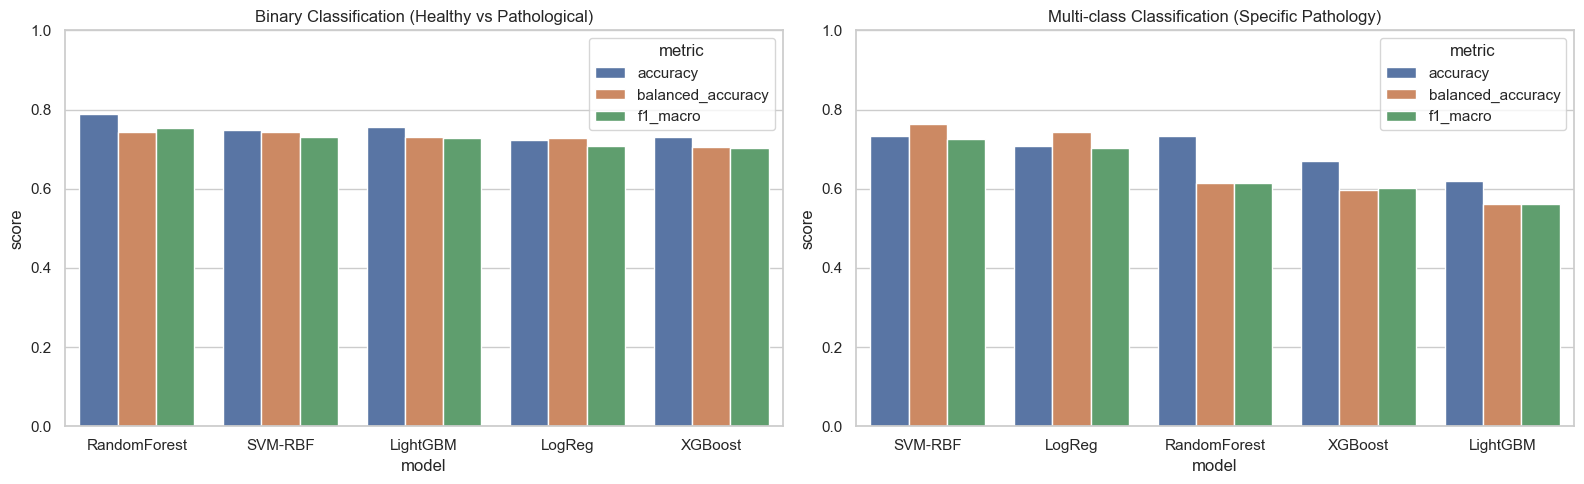

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df_bin = results_bin_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_bin, x="model", y="score", hue="metric", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Binary Classification (Healthy vs Pathological)")

plot_df_multi = results_multi_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_multi, x="model", y="score", hue="metric", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Multi-class Classification (Specific Pathology)")

plt.tight_layout()
plt.show()

In [14]:
best_model_name_bin = results_bin_df.iloc[0]["model"]
best_pipe_bin, best_pred_bin = trained_pipelines_bin[best_model_name_bin]

print(f"Best Binary Model: {best_model_name_bin}")
print(classification_report(y_bin_test, best_pred_bin, zero_division=0))

best_model_name_multi = results_multi_df.iloc[0]["model"]
best_pipe_multi, best_pred_multi = trained_pipelines_multi[best_model_name_multi]

print(f"\nBest Multi-class Model: {best_model_name_multi}")
print(classification_report(y_multi_test_patho, best_pred_multi, zero_division=0))

Best Binary Model: RandomForest
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        79
           1       0.73      0.60      0.66        40

    accuracy                           0.79       119
   macro avg       0.77      0.74      0.75       119
weighted avg       0.78      0.79      0.78       119


Best Multi-class Model: SVM-RBF
              precision    recall  f1-score   support

Neurological       0.90      0.68      0.77        53
  Structural       0.56      0.85      0.68        26

    accuracy                           0.73        79
   macro avg       0.73      0.76      0.73        79
weighted avg       0.79      0.73      0.74        79



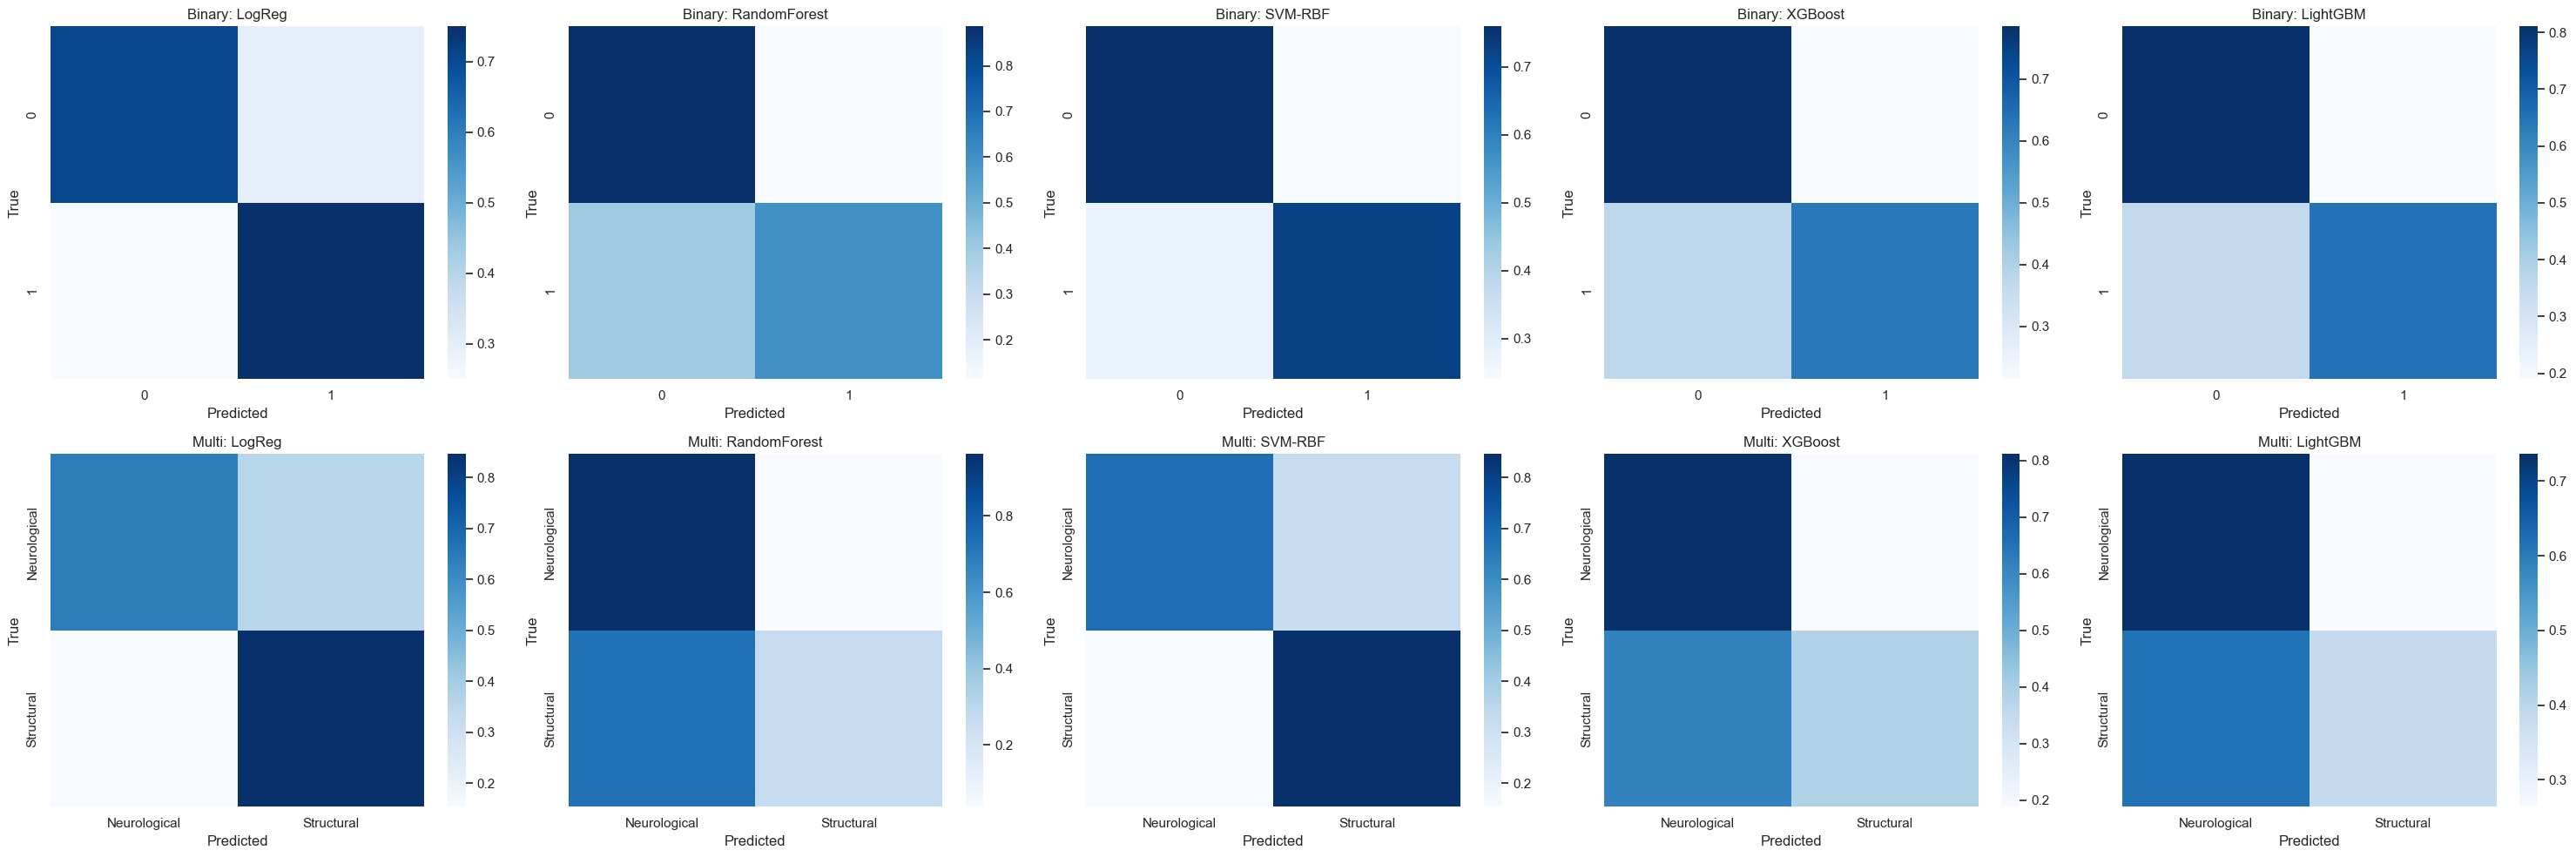

In [15]:
labels_bin = sorted(y_bin_test.unique())
labels_multi = sorted(y_multi_test_patho.unique())

n_models = len(trained_pipelines_bin)
fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10), squeeze=False)

for i, (name, (_, pred)) in enumerate(trained_pipelines_bin.items()):
    cm = confusion_matrix(y_bin_test, pred, labels=labels_bin)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_bin,
        yticklabels=labels_bin,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"Binary: {name}")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("True")

for i, (name, (_, pred)) in enumerate(trained_pipelines_multi.items()):
    cm = confusion_matrix(y_multi_test_patho, pred, labels=labels_multi)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_multi,
        yticklabels=labels_multi,
        ax=axes[1, i],
    )
    axes[1, i].set_title(f"Multi: {name}")
    axes[1, i].set_xlabel("Predicted")
    axes[1, i].set_ylabel("True")

plt.tight_layout()
plt.show()

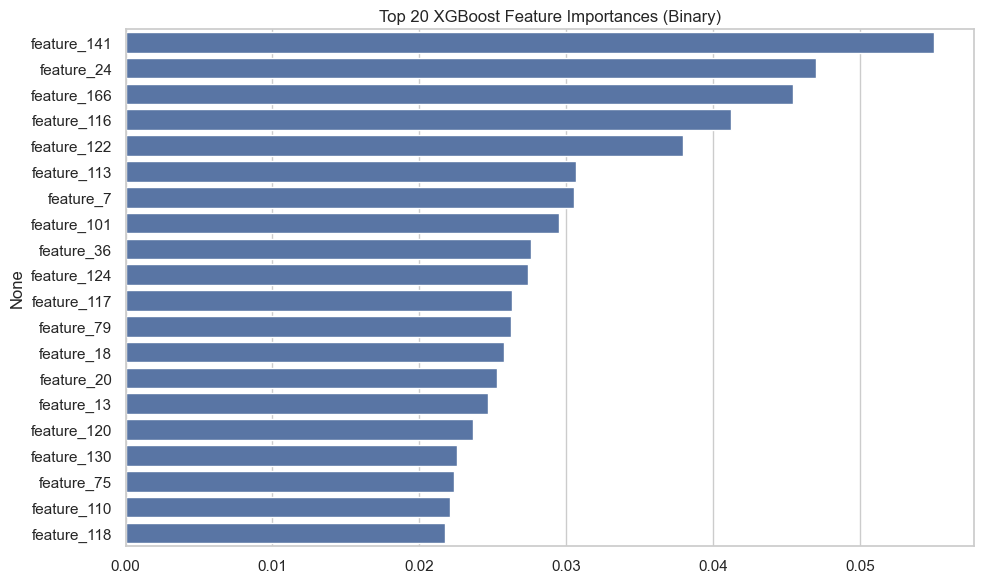

,importance
feature_141,0.054980
feature_24,0.046980
feature_166,0.045390
feature_116,0.041171
feature_122,0.037912
feature_113,0.030681
feature_7,0.030542
feature_101,0.029482
feature_36,0.027619
feature_124,0.027373


In [16]:
# Inspect top feature importances for the best binary model (XGBoost)
if "XGBoost" in trained_pipelines_bin:
    xgb_pipe, _ = trained_pipelines_bin["XGBoost"]
    xgb_model = xgb_pipe.named_steps["model"]
    selector = xgb_pipe.named_steps["selector"]
    preprocessor_step = xgb_pipe.named_steps["prep"]

    sel_mask = selector.get_support()
    n_features = len(sel_mask)
    
    # Robustly reconstruct feature names (same logic as above)
    features_after_prep = None
    
    try:
        names = preprocessor_step.get_feature_names_out()
        if len(names) == n_features:
            features_after_prep = names
    except (AttributeError, ValueError):
        pass

    if features_after_prep is None:
        try:
            var_mask = preprocessor_step.named_transformers_["num"].named_steps["variance"].get_support()
            num_names = np.array(numeric_feature_cols)[var_mask]
            cat_names = preprocessor_step.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_feature_cols)
            names = np.concatenate([num_names, cat_names])
            if len(names) == n_features:
                features_after_prep = names
        except Exception:
            pass

    if features_after_prep is None:
        features_after_prep = np.array([f"feature_{i}" for i in range(n_features)])

    final_features = features_after_prep[sel_mask]

    importances = pd.Series(xgb_model.feature_importances_, index=final_features)
    importances.index = importances.index.str.replace(r'^(num__|cat__)', '', regex=True)

    top_imp = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_imp.values, y=top_imp.index)
    plt.title(f"Top {len(top_imp)} XGBoost Feature Importances (Binary)")
    plt.tight_layout()
    plt.show()

    display(top_imp.to_frame("importance"))

In [17]:
# Hyperparameter Tuning for XGBoost (Binary Classification)
print("--- Hyperparameter Tuning (Binary Classification) ---")

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
    ("model", XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss")),
])

grid_search = GridSearchCV(
    xgb_pipe, param_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_bin_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 Macro: {grid_search.best_score_:.4f}")

best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

print("\nTuned Model Test Performance:")
print(classification_report(y_bin_test, y_pred_tuned, zero_division=0))

--- Hyperparameter Tuning (Binary Classification) ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 300}
Best CV F1 Macro: 0.9134

Tuned Model Test Performance:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        79
           1       0.67      0.65      0.66        40

    accuracy                           0.77       119
   macro avg       0.75      0.74      0.74       119
weighted avg       0.77      0.77      0.77       119



In [18]:
# Hyperparameter Tuning for XGBoost (Multi-class Classification)
print("--- Hyperparameter Tuning (Multi-class Classification) ---")

param_grid_multi = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

xgb_pipe_multi = Pipeline(steps=[
    ("prep", preprocessor),
    ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
    ("model", XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="mlogloss")),
])

grid_search_multi = GridSearchCV(
    xgb_pipe_multi, param_grid_multi, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search_multi.fit(X_train_patho, y_multi_train_patho_enc)

print(f"Best parameters: {grid_search_multi.best_params_}")
print(f"Best CV F1 Macro: {grid_search_multi.best_score_:.4f}")

best_tuned_model_multi = grid_search_multi.best_estimator_
y_pred_tuned_enc = best_tuned_model_multi.predict(X_test_patho)
y_pred_tuned_multi = le.inverse_transform(y_pred_tuned_enc)

print("\nTuned Model Test Performance (Multi-class):")
print(classification_report(y_multi_test_patho, y_pred_tuned_multi, zero_division=0))

--- Hyperparameter Tuning (Multi-class Classification) ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV F1 Macro: 0.6401

Tuned Model Test Performance (Multi-class):
              precision    recall  f1-score   support

Neurological       0.75      0.83      0.79        53
  Structural       0.55      0.42      0.48        26

    accuracy                           0.70        79
   macro avg       0.65      0.63      0.63        79
weighted avg       0.68      0.70      0.68        79



## Changes in v2_grouped vs v1

1. **Configurable disease grouping map** — set `DISEASE_GROUP_MAP` at the top to merge related diagnoses into broader classes.
2. **Grouped target toggle** — `USE_GROUPED_TARGET` enables/disables grouping without changing downstream code.
3. **MIN_SAMPLES_PER_CLASS=50** — low-sample classes/groups are dropped after target construction.
4. **StratifiedGroupKFold split** — all remaining classes guaranteed in both train and test, with no speaker leakage across splits.
5. **SelectKBest(k=50)** — aggressive dimensionality reduction in high-dimensional feature space.
6. Diagnostic cells now show raw-diagnosis → grouped-target mapping and class distribution before/after filtering.

## Next steps if accuracy is still low
- Aggregate features per speaker (mean across tokens) and classify at speaker level
- Try coarser/finer grouping maps and compare macro-F1
- Add class-weight calibration or focal-loss-style surrogates for heavily imbalanced groups

In [19]:
# Quick diagnostics: why binary score changed
print('USE_GROUPED_TARGET:', USE_GROUPED_TARGET)
print('MIN_SAMPLES_PER_CLASS:', MIN_SAMPLES_PER_CLASS)
print('TARGET:', target_col)

print('\nOverall binary class counts (0=pathological, 1=healthy):')
print(y_binary.value_counts(dropna=False).sort_index())

print('\nTrain binary class counts:')
print(y_bin_train.value_counts(dropna=False).sort_index())
print('Test binary class counts:')
print(y_bin_test.value_counts(dropna=False).sort_index())

print('\nTrain grouped pathology counts (all):')
print(y_multi_train.value_counts())
print('\nTest grouped pathology counts (all):')
print(y_multi_test.value_counts())

rf_row = results_bin_df[results_bin_df['model'] == 'RandomForest']
if not rf_row.empty:
    print('\nRandomForest binary metrics:')
    print(rf_row[['accuracy','balanced_accuracy','f1_macro']])

rf_pred = trained_pipelines_bin['RandomForest'][1]
print('\nRandomForest confusion matrix (rows=true, cols=pred):')
print(pd.DataFrame(confusion_matrix(y_bin_test, rf_pred, labels=sorted(y_bin_test.unique())),
                  index=[f'true_{c}' for c in sorted(y_bin_test.unique())],
                  columns=[f'pred_{c}' for c in sorted(y_bin_test.unique())]))

USE_GROUPED_TARGET: True
MIN_SAMPLES_PER_CLASS: 50
TARGET: target_label

Overall binary class counts (0=pathological, 1=healthy):
is_healthy
0    395
1    200
Name: count, dtype: int64

Train binary class counts:
is_healthy
0    316
1    160
Name: count, dtype: int64
Test binary class counts:
is_healthy
0    79
1    40
Name: count, dtype: int64

Train grouped pathology counts (all):
target_label
Neurological    212
healthy         160
Structural      104
Name: count, dtype: int64

Test grouped pathology counts (all):
target_label
Neurological    53
healthy         40
Structural      26
Name: count, dtype: int64

RandomForest binary metrics:
   accuracy  balanced_accuracy  f1_macro
1  0.789916           0.743038   0.75301

RandomForest confusion matrix (rows=true, cols=pred):
        pred_0  pred_1
true_0      70       9
true_1      16      24


In [20]:
# Compact diagnostics for current run
from sklearn.metrics import confusion_matrix

print('=== DATASET SNAPSHOT ===')
print('Total samples:', len(df))
print('Unique speakers:', groups.nunique())
print('Samples per speaker (mean):', round(len(df) / max(groups.nunique(), 1), 2))

print('\n=== BINARY CLASS IMBALANCE ===')
bin_counts = y_binary.value_counts().sort_index()
print(bin_counts)
majority_acc = bin_counts.max() / bin_counts.sum()
print('Majority-class baseline accuracy:', round(float(majority_acc), 4))

print('\n=== MULTI-CLASS (PATHO ONLY) BALANCE ===')
multi_counts = y_multi[y_binary == 0].value_counts()
print(multi_counts)
majority_multi = multi_counts.max() / multi_counts.sum()
print('Majority-class baseline (patho-only):', round(float(majority_multi), 4))

print('\n=== GROUP SPLIT SANITY ===')
train_speakers = set(groups.iloc[train_idx].astype(str))
test_speakers = set(groups.iloc[test_idx].astype(str))
overlap = train_speakers.intersection(test_speakers)
print('Speaker overlap train/test:', len(overlap))

print('\n=== BEST BINARY MODEL ERROR SHAPE ===')
cm_bin = confusion_matrix(y_bin_test, best_pred_bin, labels=sorted(y_bin_test.unique()))
print(pd.DataFrame(cm_bin,
                   index=[f'true_{c}' for c in sorted(y_bin_test.unique())],
                   columns=[f'pred_{c}' for c in sorted(y_bin_test.unique())]))

print('\n=== BEST MULTI MODEL ERROR SHAPE ===')
cm_multi = confusion_matrix(y_multi_test_patho, best_pred_multi, labels=sorted(y_multi_test_patho.unique()))
print(pd.DataFrame(cm_multi,
                   index=[f'true_{c}' for c in sorted(y_multi_test_patho.unique())],
                   columns=[f'pred_{c}' for c in sorted(y_multi_test_patho.unique())]))

=== DATASET SNAPSHOT ===
Total samples: 595
Unique speakers: 457
Samples per speaker (mean): 1.3

=== BINARY CLASS IMBALANCE ===
is_healthy
0    395
1    200
Name: count, dtype: int64
Majority-class baseline accuracy: 0.6639

=== MULTI-CLASS (PATHO ONLY) BALANCE ===
target_label
Neurological    265
Structural      130
Name: count, dtype: int64
Majority-class baseline (patho-only): 0.6709

=== GROUP SPLIT SANITY ===
Speaker overlap train/test: 0

=== BEST BINARY MODEL ERROR SHAPE ===
        pred_0  pred_1
true_0      70       9
true_1      16      24

=== BEST MULTI MODEL ERROR SHAPE ===
                   pred_Neurological  pred_Structural
true_Neurological                 36               17
true_Structural                    4               22


In [21]:
# Stability check: grouped CV for best-performing model types
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

rf_template = Pipeline(steps=[
    ("prep", preprocessor),
    ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )),
])

svm_template = Pipeline(steps=[
    ("prep", preprocessor),
    ("selector", SelectKBest(f_classif, k=N_SELECT_FEATURES)),
    ("model", SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced")),
])

bin_scores = []
for tr, te in cv.split(X, y_binary, groups):
    m = clone(rf_template)
    m.fit(X.iloc[tr], y_binary.iloc[tr])
    p = m.predict(X.iloc[te])
    bin_scores.append({
        'acc': accuracy_score(y_binary.iloc[te], p),
        'bacc': balanced_accuracy_score(y_binary.iloc[te], p),
        'f1m': f1_score(y_binary.iloc[te], p, average='macro', zero_division=0),
    })

bin_scores_df = pd.DataFrame(bin_scores)
print('Binary RF grouped 5-fold CV (mean ± std)')
print((bin_scores_df.mean().round(4)).astype(str) + ' ± ' + (bin_scores_df.std().round(4)).astype(str))

# Multi-class pathological grouped CV
X_patho_all = X[y_binary == 0].copy()
y_patho_all = y_multi[y_binary == 0].copy()
g_patho_all = groups[y_binary == 0].copy()

multi_scores = []
for tr, te in cv.split(X_patho_all, y_patho_all, g_patho_all):
    le_cv = LabelEncoder()
    y_tr_enc = le_cv.fit_transform(y_patho_all.iloc[tr])

    m = clone(svm_template)
    m.fit(X_patho_all.iloc[tr], y_tr_enc)

    pred_enc = m.predict(X_patho_all.iloc[te])
    pred = le_cv.inverse_transform(pred_enc)

    multi_scores.append({
        'acc': accuracy_score(y_patho_all.iloc[te], pred),
        'bacc': balanced_accuracy_score(y_patho_all.iloc[te], pred),
        'f1m': f1_score(y_patho_all.iloc[te], pred, average='macro', zero_division=0),
    })

multi_scores_df = pd.DataFrame(multi_scores)
print('\nPathology grouped 5-fold CV (mean ± std)')
print((multi_scores_df.mean().round(4)).astype(str) + ' ± ' + (multi_scores_df.std().round(4)).astype(str))

Binary RF grouped 5-fold CV (mean ± std)
acc     0.7547 ± 0.0566
bacc    0.7029 ± 0.0634
f1m     0.7109 ± 0.0673
dtype: str

Pathology grouped 5-fold CV (mean ± std)
acc     0.6862 ± 0.0813
bacc    0.6505 ± 0.0788
f1m     0.6486 ± 0.0836
dtype: str
